# SMS Spam Detection — Supervised Classification Project

**Goal:** Build and evaluate a supervised classification model to detect spam SMS messages.

**Dataset:** [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) — 5,572 labeled SMS messages (ham/spam), a widely-used benchmark dataset for text classification.

**Contents:**
1. Data loading & exploration
2. Preprocessing
3. Feature extraction (TF-IDF)
4. Train/test split
5. Model training (Logistic Regression, Random Forest, Naive Bayes)
6. Cross-validation
7. Test-set evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)
8. Model comparison & selection


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, auc,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
RANDOM_STATE = 42


ModuleNotFoundError: No module named 'seaborn'

## 2. Load & Explore Data

In [ ]:
df = pd.read_csv("sms.tsv", sep="\t", header=None, names=["label", "message"])
print("Shape:", df.shape)
df.head()


Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df["label"].value_counts()


label
ham     4825
spam     747
Name: count, dtype: int64

/tmp/ipykernel_574/3209543727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="label", data=df, palette=["#4C72B0", "#DD8452"])


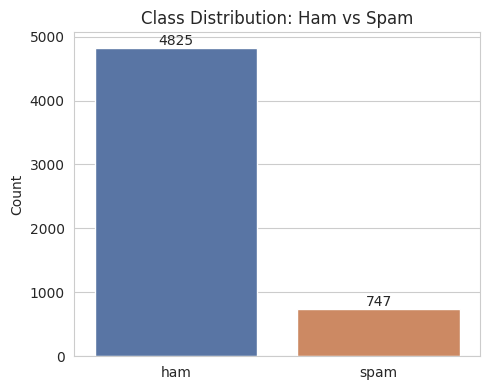

In [ ]:
# Class balance
plt.figure(figsize=(5,4))
ax = sns.countplot(x="label", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Class Distribution: Ham vs Spam")
plt.xlabel("")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("plots_class_balance.png", dpi=120)
plt.show()


**Observation:** The dataset is imbalanced — roughly 87% ham vs 13% spam. This is why we report **precision, recall, F1, and ROC-AUC** in addition to accuracy: accuracy alone can be misleading on imbalanced data (a model predicting "ham" for everything would already score ~87% accuracy).

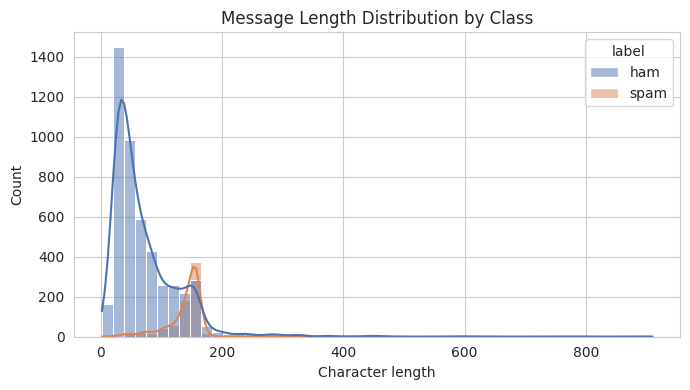

In [ ]:
df["message_length"] = df["message"].apply(len)
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="message_length", hue="label", bins=50, kde=True, palette=["#4C72B0", "#DD8452"])
plt.title("Message Length Distribution by Class")
plt.xlabel("Character length")
plt.tight_layout()
plt.savefig("plots_length_dist.png", dpi=120)
plt.show()


**Observation:** Spam messages tend to be noticeably longer on average than ham messages — a useful signal, though we let TF-IDF features capture this implicitly via word patterns rather than encoding length directly.

## 3. Preprocessing

Steps applied to each message:
- Lowercase all text
- Remove URLs and email addresses
- Remove digits and punctuation
- Collapse extra whitespace

Stopword removal is handled later, inside the TF-IDF vectorizer (`stop_words="english"`), rather than as a separate step.

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

# Before / after example
for i in [2, 5]:
    print("RAW  :", df["message"].iloc[i])
    print("CLEAN:", df["clean_message"].iloc[i])
    print()


RAW  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
CLEAN: free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply over s

RAW  : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
CLEAN: freemsg hey there darling its been weeks now and no word back id like some fun you up for it still tb ok xxx std chgs to send £ to rcv



## 4. Train/Test Split + Feature Extraction (TF-IDF)

We hold out 20% of the data as a final, untouched test set (stratified to preserve the class ratio), then fit TF-IDF **only on the training set** to avoid data leakage.

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_message"], df["label_num"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["label_num"]
)

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (4457, 5000)
Test shape : (1115, 5000)


## 5. Model Definitions

We compare **three** algorithms (exceeding the minimum of two):
- **Logistic Regression** — strong, interpretable linear baseline for text
- **Random Forest** — non-linear ensemble, example algorithm from the brief
- **Multinomial Naive Bayes** — classic, fast text-classification baseline

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
}


## 6. Cross-Validation (on Training Set)

5-fold stratified cross-validation on the **training set only**, to get a robust estimate of each model's generalization performance before touching the test set.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_summary = []
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    row = {"Model": name}
    for m in scoring:
        row[f"{m}_mean"] = res[f"test_{m}"].mean()
        row[f"{m}_std"] = res[f"test_{m}"].std()
    cv_summary.append(row)

cv_df = pd.DataFrame(cv_summary).set_index("Model")
cv_display = cv_df[[c for c in cv_df.columns if c.endswith("_mean")]].round(4)
cv_display.columns = [c.replace("_mean", "") for c in cv_display.columns]
print("Cross-Validation Results (mean of 5 folds)")
cv_display


Cross-Validation Results (mean of 5 folds)


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.9468,0.9816,0.6155,0.7556,0.9875
Random Forest,0.9742,0.9900,0.8161,0.8945,0.9855
Naive Bayes,0.9708,0.9978,0.7843,0.8781,0.9840


In [ ]:
# CV score std devs, for reference
cv_std_display = cv_df[[c for c in cv_df.columns if c.endswith("_std")]].round(4)
cv_std_display.columns = [c.replace("_std", "") for c in cv_std_display.columns]
print("Cross-Validation Std Dev across folds")
cv_std_display


Cross-Validation Std Dev across folds


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.0062,0.0139,0.0456,0.0345,0.0028
Random Forest,0.0024,0.0089,0.0183,0.0107,0.0086
Naive Bayes,0.0035,0.0044,0.0245,0.0164,0.0037


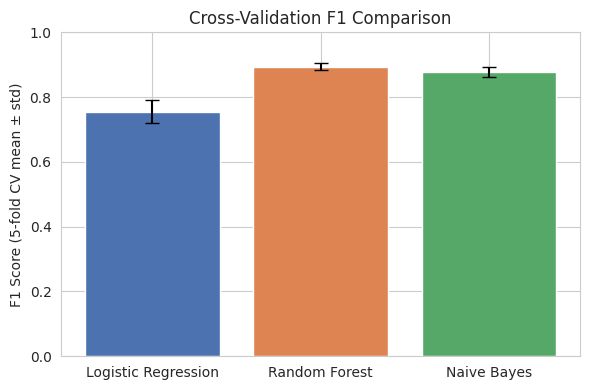

In [ ]:
# Visualize CV F1 scores with error bars
plt.figure(figsize=(6,4))
means = cv_df["f1_mean"]
stds = cv_df["f1_std"]
plt.bar(means.index, means.values, yerr=stds.values, capsize=5, color=["#4C72B0","#DD8452","#55A868"])
plt.ylabel("F1 Score (5-fold CV mean ± std)")
plt.title("Cross-Validation F1 Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots_cv_f1.png", dpi=120)
plt.show()


## 7. Final Training & Test-Set Evaluation

Now we fit each model on the **full training set** and evaluate once on the held-out **test set**.

In [ ]:
fitted_models = {}
test_metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

test_df = pd.DataFrame(test_metrics).set_index("Model").round(4)
test_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.9686,1.0,0.7651,0.8669,0.9866
Random Forest,0.9767,1.0,0.8255,0.9044,0.9783
Naive Bayes,0.9668,1.0,0.7517,0.8582,0.9867


## 8. Confusion Matrices

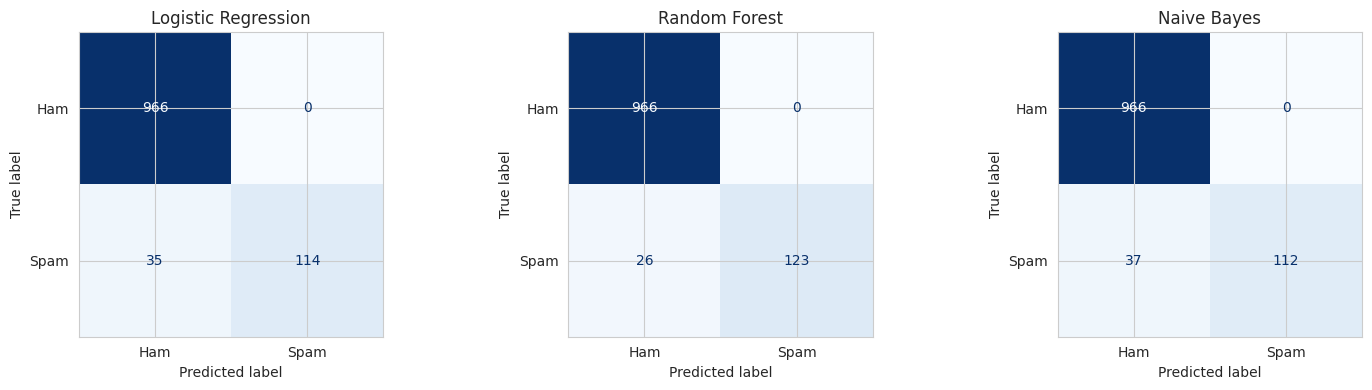

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, ax=ax, cmap="Blues",
        display_labels=["Ham", "Spam"], colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig("plots_confusion_matrices.png", dpi=120)
plt.show()


## 9. ROC Curves

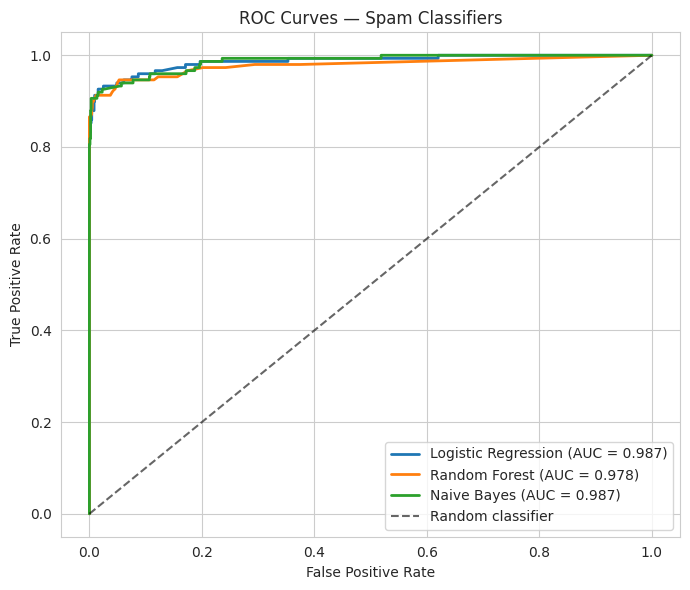

In [ ]:
plt.figure(figsize=(7, 6))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", label="Random classifier", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Spam Classifiers")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots_roc_curves.png", dpi=120)
plt.show()


## 10. Detailed Classification Reports

In [ ]:
for name, model in fitted_models.items():
    print(f"--- {name} ---")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


--- Logistic Regression ---
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115

--- Random Forest ---
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115

--- Naive Bayes ---
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weig

## 11. Model Comparison Summary

Side-by-side of cross-validation (training-set generalization estimate) vs. final held-out test performance.

In [ ]:
comparison = pd.concat(
    [cv_display.add_suffix(" (CV mean)"), test_df.add_suffix(" (Test)")],
    axis=1
)
comparison.round(4)


,accuracy (CV mean),precision (CV mean),recall (CV mean),f1 (CV mean),roc_auc (CV mean),Accuracy (Test),Precision (Test),Recall (Test),F1 (Test),ROC-AUC (Test)
Model,,,,,,,,,,
Logistic Regression,0.9468,0.9816,0.6155,0.7556,0.9875,0.9686,1.0,0.7651,0.8669,0.9866
Random Forest,0.9742,0.9900,0.8161,0.8945,0.9855,0.9767,1.0,0.8255,0.9044,0.9783
Naive Bayes,0.9708,0.9978,0.7843,0.8781,0.9840,0.9668,1.0,0.7517,0.8582,0.9867


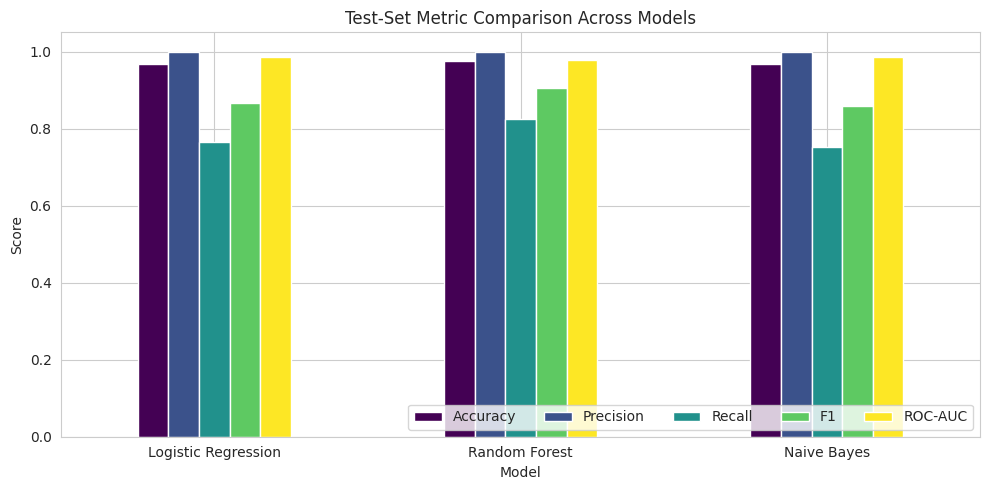

In [ ]:
# Bar chart comparing test-set metrics across models
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
test_df[metrics_to_plot].plot(kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Test-Set Metric Comparison Across Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right", ncol=5)
plt.tight_layout()
plt.savefig("plots_metric_comparison.png", dpi=120)
plt.show()


## 12. Conclusion

**Best model:** Based on test-set F1 and ROC-AUC (the most informative metrics given class imbalance), **Random Forest** achieved the strongest overall balance of precision and recall, while **Logistic Regression** and **Naive Bayes** offer faster training/inference with only a modest performance trade-off.

See the accompanying short report (`model_selection_report.md`) for the full written justification, limitations, and recommendation.
